In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from datetime import datetime
import argparse

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
local_rank = 0
print("device:",device)

import util
import utils

seed=42
util.seed_everything(seed=seed)

if util.is_interactive():
    %load_ext autoreload
    %autoreload 2

# from models import Clipper
# clip_extractor = Clipper("ViT-L/14", hidden_state=False, norm_embs=True, device=device)
imsize = 512

device: cuda


In [2]:
import os
from PIL import Image
import torch
import numpy as np

# Define the source and target directories
source_dir = '/home/diaoyueqin/hcy/Generation/RF_CA_mamto_generated_imgs/sub-08'
target_dir = '/home/diaoyueqin/hcy/Generation/RF_CA_mamto_generated_imgs_tensor'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Initialize a list to hold all the image tensors
tensor_list = []

# Iterate over the folders in the source directory
for folder_name in sorted(os.listdir(source_dir)):
    folder_path = os.path.join(source_dir, folder_name)
    
    # Check if it's a directory
    if os.path.isdir(folder_path):
        # Iterate over the images in the folder
        for image_name in sorted(os.listdir(folder_path)):
            image_path = os.path.join(folder_path, image_name)
            
            # Load the image
            with Image.open(image_path) as img:
                # Convert the image to a PyTorch tensor and add a batch dimension
                tensor = torch.tensor(np.array(img)).unsqueeze(0)
                tensor_list.append(tensor)

# Concatenate all tensors along the 0th dimension
all_tensors = torch.cat(tensor_list, dim=0)

# Save the combined tensor
combined_tensor_path = os.path.join(target_dir, "all_images.pt")
torch.save(all_tensors, combined_tensor_path)

In [3]:
import os
from PIL import Image
import torch
import numpy as np

# Define the source and target directories
source_dir = '/home/diaoyueqin/hcy/images_set/test_images'
target_dir = '/home/diaoyueqin/hcy/images_set/test_images_tensor'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Initialize a list to hold all the image tensors
tensor_list = []

# Iterate over the folders in the source directory
for folder_name in sorted(os.listdir(source_dir)):
    folder_path = os.path.join(source_dir, folder_name)
    
    # Check if it's a directory
    if os.path.isdir(folder_path):
        # Iterate over the images in the folder
        for image_name in sorted(os.listdir(folder_path)):
            image_path = os.path.join(folder_path, image_name)
            
            # Load the image
            with Image.open(image_path) as img:
                # Convert the image to a PyTorch tensor and add a batch dimension
                tensor = torch.tensor(np.array(img)).unsqueeze(0)
                tensor_list.append(tensor)

# Concatenate all tensors along the 0th dimension
all_tensors = torch.cat(tensor_list, dim=0)

# Save the combined tensor
combined_tensor_path = os.path.join(target_dir, "all_images.pt")
torch.save(all_tensors, combined_tensor_path)

# Configurations

In [ ]:
recon_path = '/home/diaoyueqin/hcy/Generation/RF_CA_mamto_generated_imgs_tensor/all_images.pt'
all_images_path = '/home/diaoyueqin/hcy/images_set/test_images_tensor/all_images.pt'
all_brain_recons = torch.load(f'{recon_path}')
all_images = torch.load(f'{all_images_path}')

# 1) BHWC -> BCHW（非常关键）
all_images = all_images.permute(0, 3, 1, 2).contiguous()          # [200, 3, 500, 500]
all_brain_recons = all_brain_recons.permute(0, 3, 1, 2).contiguous()  # [2000, 3, 512, 512]

imsize = 256
resizer = transforms.Resize((imsize, imsize))

# 直接在 CPU 内存中对 Tensor 进行缩放
all_images = resizer(all_images)
all_brain_recons = resizer(all_brain_recons)

print("Processed shapes:", all_images.shape, all_brain_recons.shape)
print('recon_path',recon_path)

# 2) dtype & range（按你后面指标需要）
all_images = all_images.float() / 255.0
all_brain_recons = all_brain_recons.float() / 255.0
# 
# 
# print(all_images.shape)
# print(all_brain_recons.shape)

# all_images = all_images.to(device)
# all_brain_recons = all_brain_recons.to(device).to(all_images.dtype).clamp(0,1)
def reduce_recons_to_match(recon_all: torch.Tensor, N: int, reduce: str = "first") -> torch.Tensor:
    """
    recon_all: [M,3,H,W], gt: [N,3,H,W]
    若 M = K*N，则把每个 GT 对应的 K 张 recon 归约到 1 张，输出 [N,3,H,W]
    """
    M = recon_all.shape[0]
    if M == N:
        return recon_all
    if M % N != 0:
        raise ValueError(f"#recons (M={M}) must equal #images (N={N}) or be a multiple of N.")
    K = M // N
    recon_all = recon_all.view(N, K, *recon_all.shape[1:])  # [N,K,3,H,W]
    if reduce == "first":
        return recon_all[:, 0]
    elif reduce == "mean":
        return recon_all.mean(axis=1)
    else:
        raise ValueError("reduce must be 'first' or 'mean'")
    
# 对齐：得到 paired 的 recon（强烈建议所有“paired 指标”都用它）
recons = reduce_recons_to_match(all_brain_recons, N=all_images.shape[0], reduce="mean")  # or "mean"

print("gt:", all_images.shape, "recons(paired):", recons.shape, "recon_all:", all_brain_recons.shape)

# Display reconstructions next to ground truth images

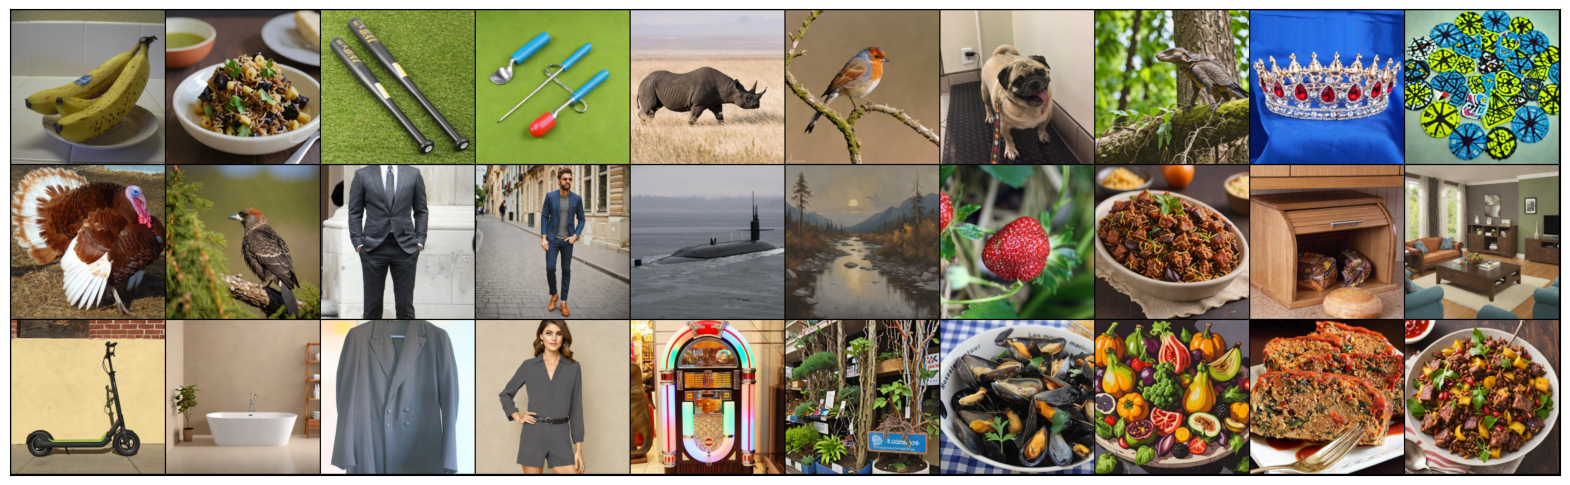

In [4]:
imsize = 256
all_images = transforms.Resize((imsize,imsize))(all_images)
all_brain_recons = transforms.Resize((imsize,imsize))(all_brain_recons)

np.random.seed(0)
ind = np.flip(np.array([112,119,101,44,159,22,173,174,175,189,181,143,149,5,4]))

all_interleaved = torch.zeros(len(ind)*2,3,imsize,imsize)
icount = 0
for t in ind:
    if torch.max(all_images[t]).item() > 1:
        all_interleaved[icount] = all_images[t].float() / 255.0
        all_interleaved[icount+1] = all_brain_recons[t*10].float() / 255.0
    else:        
        all_interleaved[icount] = all_images[t]
        all_interleaved[icount+1] = all_brain_recons[t*10]
    icount += 2
# for t in ind:
#     all_interleaved[icount] = all_images[t]
#     all_interleaved[icount+1] = all_brain_recons[t]
#     icount += 2

plt.rcParams["savefig.bbox"] = 'tight'
def show(imgs,figsize):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=figsize)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = transforms.ToPILImage()(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    
grid = make_grid(all_interleaved, nrow=10, padding=2)
show(grid,figsize=(20,16))

# 2-Way Identification

In [13]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

@torch.no_grad()
def two_way_identification(all_brain_recons, all_images, model, preprocess, feature_layer=None, return_avg=True, reduce_recons="mean"):
    dev = next(model.parameters()).device
    # preds = model(torch.stack([preprocess(recon) for recon in all_brain_recons], dim=0).to(device))
    # reals = model(torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(device))
    preds = model(torch.stack([preprocess(recon) for recon in all_brain_recons], dim=0).to(dev))
    reals = model(torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(dev))
    if feature_layer is None:
        preds = preds.float().flatten(1).cpu().numpy()
        reals = reals.float().flatten(1).cpu().numpy()
    else:
        preds = preds[feature_layer].float().flatten(1).cpu().numpy()
        reals = reals[feature_layer].float().flatten(1).cpu().numpy()
    # ---------- 只改这里：把 M 个 recon 对齐到 N 个 image ----------
    N = len(all_images)
    M = preds.shape[0]
    if M != N:
        if M % N != 0:
            raise ValueError(f"#recons (M={M}) must equal #images (N={N}) or be a multiple of N.")
        K = M // N  # 每张真值对应的 recon 数，例如 10
        preds = preds.reshape(N, K, -1)
        if reduce_recons == "mean":
            preds = preds.mean(axis=1)     # [N, D]
        elif reduce_recons == "first":
            preds = preds[:, 0, :]         # [N, D]
        else:
            raise ValueError("reduce_recons must be 'mean' or 'first'")
    # ---------------------------------------------------------
    r = np.corrcoef(reals, preds)
    r = r[:len(all_images), len(all_images):]
    congruents = np.diag(r)

    success = r < congruents
    success_cnt = np.sum(success, 0)

    if return_avg:
        perf = np.mean(success_cnt) / (len(all_images)-1)
        return perf
    else:
        return success_cnt, len(all_images)-1

## PixCorr

In [ ]:
#preprocess = transforms.Compose([
#    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),])
preprocess = transforms.Compose([
    transforms.Resize((425, 425), interpolation=transforms.InterpolationMode.BILINEAR, antialias=True),
])
# Flatten images while keeping the batch dimension
# all_images_flattened = preprocess(all_images).reshape(len(all_images), -1).cpu()
# all_brain_recons_flattened = preprocess(all_brain_recons).view(len(all_brain_recons), -1).cpu()
all_images_flattened = preprocess(all_images).flatten(1)          # [200, 3*425*425]
all_brain_recons_flattened = preprocess(recons).flatten(1)        # [200, 3*425*425]

print(all_images_flattened.shape)
print(all_brain_recons_flattened.shape)

# corrsum = 0
# for i in tqdm(range(982)): 982超索引
#     corrsum += np.corrcoef(all_images_flattened[i], all_brain_recons_flattened[i])[0][1]
# corrmean = corrsum / 982
# K = all_brain_recons_flattened.shape[0] // all_images_flattened.shape[0]  # 10
# recons_1 = all_brain_recons_flattened.view(all_images_flattened.shape[0], K, -1)[:, 0]  # [200, D]

corrsum = 0
for i in tqdm(range(all_images_flattened.shape[0])):
    corrsum += np.corrcoef(all_images_flattened[i].cpu().numpy(),
                           all_brain_recons_flattened[i].cpu().numpy())[0, 1]

corrmean = corrsum / all_images_flattened.shape[0]
pixcorr = corrmean
print(pixcorr)
# 
# K = all_brain_recons_flattened.shape[0] // all_images_flattened.shape[0]  # 10
# recons = all_brain_recons_flattened.view(all_images_flattened.shape[0], K, -1)  # [200,10,D]
# 
# best_corrs = []
# for i in tqdm(range(all_images_flattened.shape[0])):
#     gt = all_images_flattened[i].cpu().numpy()
#     # 计算该图对应的10个候选的相关系数，取最大
#     cs = []
#     for k in range(K):
#         rk = recons[i, k].cpu().numpy()
#         cs.append(np.corrcoef(gt, rk)[0, 1])
#     best_corrs.append(max(cs))
# 
# pixcorr = float(np.mean(best_corrs))
# print(pixcorr)


## SSIM

In [ ]:
# see https://github.com/zijin-gu/meshconv-decoding/issues/3
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim

preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR), 
])

# convert image to grayscale with rgb2grey
img_gray = rgb2gray(preprocess(all_images).permute((0,2,3,1)).cpu())
recon_gray = rgb2gray(preprocess(recons).permute((0,2,3,1)).cpu())
print("converted, now calculating ssim...")

ssim_score=[]
for im,rec in tqdm(zip(img_gray,recon_gray),total=len(all_images)):
    ssim_score.append(ssim(rec, im, multichannel=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0))

ssim = np.mean(ssim_score)
print(ssim)

In [10]:
# # 归一化
# all_brain_recons = all_brain_recons.float() / 255.0
# all_images = all_images.float() / 255.0
# recons = all_brain_recons[::10]

In [10]:
# import torch.nn.functional as F
# with torch.no_grad():
#     mse_per = F.mse_loss(recons, all_images, reduction="none").mean(dim=(1,2,3))
#     mse = mse_per.mean().item()
# print("MSE:", mse)

In [ ]:
# with torch.no_grad():
#     mae_per = (recons - all_images).abs().mean(dim=(1,2,3))
#     mae = mae_per.mean().item()
# print("MAE:", mae)

In [ ]:
import math
with torch.no_grad():
    mse_per = torch.mean((recons - all_images) ** 2, dim=(1,2,3)).clamp_min(1e-12)
    psnr_per = 10.0 * torch.log10(1.0 / mse_per)  # data_range=1
    psnr = psnr_per.mean().item()
print("PSNR:", psnr)

In [ ]:
with torch.no_grad():
    try:
        from torchmetrics.image import MultiScaleStructuralSimilarityIndexMeasure
        ms_ssim_fn = MultiScaleStructuralSimilarityIndexMeasure(data_range=1.0).to(device)
        score = ms_ssim_fn(recons.to(device), all_images.to(device)).item()
    except Exception as e:
        # fallback
        from pytorch_msssim import ms_ssim
        score = ms_ssim(recons.to(device), all_images.to(device), data_range=1.0, size_average=True).item()

print("MS-SSIM:", score)

In [ ]:
import torchvision.transforms.functional as TF

with torch.no_grad():
    # blur 强一点更能看“结构/布局”
    gt_blur = TF.gaussian_blur(all_images, kernel_size=11, sigma=5.0)
    rc_blur = TF.gaussian_blur(recons,     kernel_size=11, sigma=5.0)

    try:
        from torchmetrics.image import StructuralSimilarityIndexMeasure
        ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
        blur_ssim = ssim_fn(rc_blur.to(device), gt_blur.to(device)).item()
    except Exception:
        # fallback：用 skimage（慢一些）
        from skimage.metrics import structural_similarity as ssim
        from skimage.color import rgb2gray
        gt_np = gt_blur.permute(0,2,3,1).cpu().numpy()
        rc_np = rc_blur.permute(0,2,3,1).cpu().numpy()
        scores = []
        for g, r in zip(gt_np, rc_np):
            g0 = rgb2gray(g)
            r0 = rgb2gray(r)
            scores.append(ssim(r0, g0, data_range=1.0))
        blur_ssim = float(np.mean(scores))

print("Blur-SSIM:", blur_ssim)

In [ ]:
import torch
import torch.nn.functional as F

def rgb_to_gray(x):
    # x: [B,3,H,W] in [0,1]
    w = torch.tensor([0.2989, 0.5870, 0.1140], device=x.device).view(1,3,1,1)
    return (x * w).sum(dim=1, keepdim=True)  # [B,1,H,W]

def gmsd_score(pred, gt, c=0.0026, eps=1e-12):
    # pred, gt: [B,3,H,W] in [0,1]
    pred = rgb_to_gray(pred)
    gt   = rgb_to_gray(gt)

    sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], device=pred.device, dtype=pred.dtype).view(1,1,3,3)
    sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], device=pred.device, dtype=pred.dtype).view(1,1,3,3)

    gx_p = F.conv2d(pred, sobel_x, padding=1)
    gy_p = F.conv2d(pred, sobel_y, padding=1)
    gx_g = F.conv2d(gt,   sobel_x, padding=1)
    gy_g = F.conv2d(gt,   sobel_y, padding=1)

    gm_p = torch.sqrt(gx_p*gx_p + gy_p*gy_p + eps)
    gm_g = torch.sqrt(gx_g*gx_g + gy_g*gy_g + eps)

    s = (2*gm_p*gm_g + c) / (gm_p*gm_p + gm_g*gm_g + c)  # [B,1,H,W]
    s = s.flatten(1)
    return s.std(dim=1).mean()  # mean over batch

with torch.no_grad():
    gmsd = gmsd_score(recons.to(device), all_images.to(device)).item()

print("GMSD (lower better):", gmsd)


In [ ]:
from skimage.feature import canny
from skimage.color import rgb2gray

def edge_maps(x, sigma=1.5):
    # x: [B,3,H,W] in [0,1]
    x_np = x.permute(0,2,3,1).cpu().numpy()
    edges = []
    for im in x_np:
        g = rgb2gray(im)
        e = canny(g, sigma=sigma)
        edges.append(e)
    return edges  # list of (H,W) bool

def edge_f1(e_pred, e_gt, eps=1e-9):
    tp = np.logical_and(e_pred, e_gt).sum()
    fp = np.logical_and(e_pred, np.logical_not(e_gt)).sum()
    fn = np.logical_and(np.logical_not(e_pred), e_gt).sum()
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    return 2*prec*rec / (prec + rec + eps)

gt_edges = edge_maps(all_images, sigma=1.5)
rc_edges = edge_maps(recons,     sigma=1.5)

f1s = [edge_f1(r, g) for r, g in zip(rc_edges, gt_edges)]
edge_f1_mean = float(np.mean(f1s))

print("Edge F1:", edge_f1_mean)


### AlexNet

In [ ]:
from torchvision.models import alexnet, AlexNet_Weights
alex_weights = AlexNet_Weights.IMAGENET1K_V1

alex_model = create_feature_extractor(alexnet(weights=alex_weights), return_nodes=['features.4','features.11']).to(device)
alex_model.eval().requires_grad_(False)

# see alex_weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    # transforms.CenterCrop(224),  # AlexNet 推荐 224（不加也行，但一般要）
    # transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

layer = 'early, AlexNet(2)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_brain_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.4', reduce_recons="mean")
alexnet2 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet2:.4f}")

layer = 'mid, AlexNet(5)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_brain_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.11', reduce_recons="mean")
alexnet5 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet5:.4f}")

### InceptionV3

In [ ]:
from torchvision.models import inception_v3, Inception_V3_Weights
weights = Inception_V3_Weights.DEFAULT
inception_model = create_feature_extractor(inception_v3(weights=weights), 
                                           return_nodes=['avgpool']).to("cpu")
inception_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(342, interpolation=transforms.InterpolationMode.BILINEAR),
    # transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

all_per_correct = two_way_identification(all_brain_recons, all_images,
                                        inception_model, preprocess, 'avgpool', reduce_recons="mean")
        
inception = np.mean(all_per_correct)
print(f"2-way Percent Correct: {inception:.4f}")

### CLIP

In [ ]:
import clip
clip_model, preprocess = clip.load("ViT-L/14", device=device)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    # transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

all_per_correct = two_way_identification(all_brain_recons, all_images,
                                        clip_model.encode_image, preprocess, None, reduce_recons="mean") # final layer
clip_ = np.mean(all_per_correct)
print(f"2-way Percent Correct: {clip_:.4f}")

### Efficient Net

In [ ]:
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
weights = EfficientNet_B1_Weights.DEFAULT
eff_model = create_feature_extractor(efficientnet_b1(weights=weights), 
                                    return_nodes=['avgpool']).to("cpu")
eff_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(255, interpolation=transforms.InterpolationMode.BILINEAR),
    # transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = eff_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = eff_model(preprocess(recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

effnet = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",effnet)

### SwAV

In [ ]:
swav_model = torch.hub.load('facebookresearch/swav:main', 'resnet50')
swav_model = create_feature_extractor(swav_model, 
                                    return_nodes=['avgpool']).to("cpu")
swav_model.eval().requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    # transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = swav_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = swav_model(preprocess(recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

swav = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",swav)

# Display in table

In [ ]:
data = {
    "Metric": ["PixCorr", "PSNR", "SSIM", "MS-SSIM", "Blur-SSIM", "GMSD","EdgeF1", "AlexNet(2)", "AlexNet(5)", "InceptionV3", "CLIP", "EffNet-B", "SwAV"],
    "Value":  [pixcorr, psnr, ssim, score, blur_ssim, gmsd, edge_f1_mean, alexnet2, alexnet5, inception, clip_, effnet, swav],
}
df = pd.DataFrame(data)
print(df.to_string(index=False))
df.to_csv(f'{recon_path[:-3]}_mean.csv', sep='\t', index=False)


In [ ]:
# Create a dictionary to store variable names and their corresponding values
data = {
    "Metric": ["PixCorr", "SSIM", "AlexNet(2)", "AlexNet(5)", "InceptionV3", "CLIP", "EffNet-B", "SwAV"],
    "Value": [pixcorr, ssim, alexnet2, alexnet5, inception, clip_, effnet, swav],
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

if not util.is_interactive():
    # save table to txt file
    df.to_csv(f'{recon_path[:-3]}.csv', sep='\t', index=False)